# Product Review Theme Mining

**Objective:** Extract recurring product-experience themes without requiring sentiment or issue labels.

This notebook uses deterministic demo text so the entire unsupervised workflow remains executable offline. Generator topics are hidden from model fitting and used only for retrospective diagnostics.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build the documented demo corpus


In [2]:
TOPICS = {
  "delivery": [
    "package",
    "courier",
    "arrival",
    "late",
    "tracking",
    "box",
    "dispatch",
    "delivery"
  ],
  "quality": [
    "durable",
    "material",
    "finish",
    "broken",
    "build",
    "quality",
    "sturdy",
    "damage"
  ],
  "usability": [
    "setup",
    "instructions",
    "easy",
    "interface",
    "controls",
    "learn",
    "feature",
    "usable"
  ],
  "value": [
    "price",
    "discount",
    "expensive",
    "worth",
    "budget",
    "cost",
    "deal",
    "value"
  ]
}
ENTITY = "review"
COMMON_WORDS = ["customer", "system", "request", "team", "today", "information", "service", "workflow"]
rows = []
for topic, vocabulary in TOPICS.items():
    for row_id in range(75):
        tokens = rng.choice(vocabulary, size=7, replace=True).tolist()
        tokens += rng.choice(COMMON_WORDS, size=4, replace=True).tolist()
        if rng.random() < 0.45:
            other_topic = rng.choice([name for name in TOPICS if name != topic])
            tokens += rng.choice(TOPICS[other_topic], size=2, replace=True).tolist()
        rng.shuffle(tokens)
        rows.append({"text": " ".join(tokens), "generator_topic": topic, "record_id": f"{topic[:3]}-{row_id:03d}"})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Corpus: {len(data):,} {ENTITY} records")
display(data.head())
display(data["generator_topic"].value_counts().rename("records").to_frame())


Corpus: 300 review records


,text,generator_topic,record_id
0,interface today controls easy easy interface e...,usability,usa-053
1,workflow expensive service cost expensive requ...,value,val-041
2,workflow setup package easy easy tracking lear...,usability,usa-002
3,request late customer late dispatch delivery l...,delivery,del-009
4,information budget expensive request expensive...,value,val-008


,records
generator_topic,
usability,75
value,75
delivery,75
quality,75


## 3. TF-IDF representation and cluster selection


In [3]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, silhouette_score

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=500, sublinear_tf=True)
vectors = vectorizer.fit_transform(data["text"])
print(f"Vector matrix: {vectors.shape[0]} documents × {vectors.shape[1]} features")

selection_rows = []
for k in range(2, 7):
    candidate = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(vectors)
    selection_rows.append({"k": k, "silhouette": silhouette_score(vectors, labels, metric="cosine"), "inertia": candidate.inertia_})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))

best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
model = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE)
data["cluster"] = model.fit_predict(vectors)
print(f"Selected k={best_k} from cosine silhouette; score={selection['silhouette'].max():.4f}")


Vector matrix: 300 documents × 500 features
Selected k=4 from cosine silhouette; score=0.1426


,k,silhouette,inertia
0,2,0.0789,264.1458
1,3,0.1109,252.1827
2,4,0.1426,240.4884
3,5,0.1181,237.9492
4,6,0.0956,235.4311


## 4. Interpret discovered clusters


In [4]:
terms = np.asarray(vectorizer.get_feature_names_out())
top_terms = []
for cluster_id, center in enumerate(model.cluster_centers_):
    words = terms[np.argsort(center)[-10:][::-1]]
    top_terms.append({"cluster": cluster_id, "records": int((data["cluster"] == cluster_id).sum()), "top_terms": ", ".join(words)})
display(pd.DataFrame(top_terms))
display(pd.crosstab(data["generator_topic"], data["cluster"], margins=True))
ari = adjusted_rand_score(data["generator_topic"], data["cluster"])
print(f"Retrospective ARI against hidden generator topics: {ari:.4f}")
print("The generator topic was not provided to TF-IDF or K-Means.")


Retrospective ARI against hidden generator topics: 1.0000
The generator topic was not provided to TF-IDF or K-Means.


,cluster,records,top_terms
0,0,75,"damage, sturdy, material, finish, durable, bro..."
1,1,75,"easy, instructions, setup, controls, feature, ..."
2,2,75,"tracking, box, late, courier, dispatch, arriva..."
3,3,75,"worth, expensive, budget, cost, discount, pric..."


cluster,0,1,2,3,All
generator_topic,,,,,
delivery,0,0,75,0,75
quality,75,0,0,0,75
usability,0,75,0,0,75
value,0,0,0,75,75
All,75,75,75,75,300


## 5. Two-dimensional map and stability check


Cluster stability across two random seeds (ARI): 1.0000


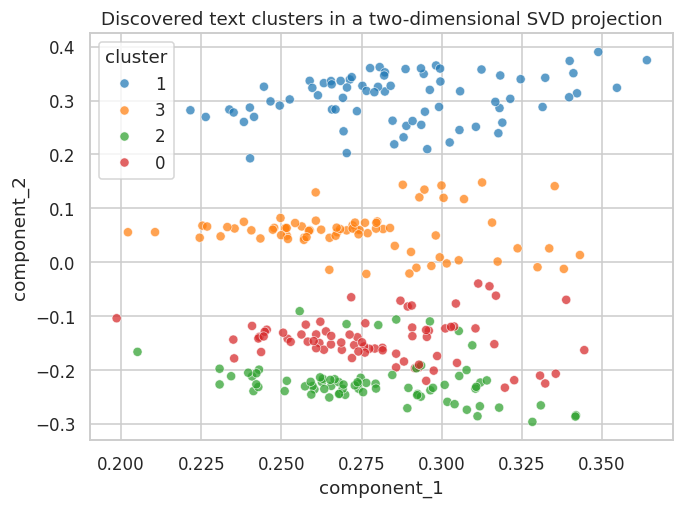

In [5]:
from sklearn.decomposition import TruncatedSVD

projection = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(vectors)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.72)
plt.title("Discovered text clusters in a two-dimensional SVD projection")
plt.tight_layout()
plt.show()

alternate = KMeans(n_clusters=best_k, n_init=30, random_state=7).fit_predict(vectors)
stability = adjusted_rand_score(data["cluster"], alternate)
print(f"Cluster stability across two random seeds (ARI): {stability:.4f}")


## 6. Assign new text and inspect nearest records


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

probe = " ".join(list(TOPICS.values())[0][:5])
probe_vector = vectorizer.transform([probe])
probe_cluster = int(model.predict(probe_vector)[0])
similarities = cosine_similarity(probe_vector, vectors).ravel()
nearest = np.argsort(similarities)[-5:][::-1]
print(f"Probe: {probe}")
print(f"Assigned cluster: {probe_cluster}")
display(data.loc[nearest, ["record_id", "text", "cluster"]].assign(cosine_similarity=similarities[nearest]).round(4))


Probe: package courier arrival late tracking
Assigned cluster: 2


,record_id,text,cluster,cosine_similarity
190,del-061,workflow system arrival information package co...,2,0.4404
278,del-048,courier arrival dispatch customer courier arri...,2,0.3601
281,del-021,arrival information request quality arrival re...,2,0.3550
68,del-056,arrival system customer workflow package couri...,2,0.3494
139,del-002,late system tracking late information dispatch...,2,0.3362


## 7. Findings and limitations

- Cluster quality is evaluated with cohesion, stability, interpretable terms, and a hidden synthetic diagnostic.
- The synthetic corpus proves the workflow, not production accuracy.
- Production use should replace TF-IDF with validated domain embeddings when semantic nuance matters.
- Topics should be reviewed by domain experts before they drive routing or policy decisions.
